<a href="https://colab.research.google.com/github/Lochan9866/Machine_Learning_Projects/blob/main/Human_Action_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Human Action Detection**

**Step 1:Importing Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
 from sklearn.utils import resample
 from sklearn.preprocessing import LabelEncoder
 from sklearn.preprocessing import RobustScaler, StandardScaler
 from sklearn.model_selection import train_test_split, GridSearchCV


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import statsmodels.api as sm

In [5]:
from sklearn.metrics import classification_report, r2_score, accuracy_score, recall_score,    \
precision_score,f1_score, confusion_matrix,mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

**Step 2:- Data Importing and Analysis**

In [6]:
df = pd.read_csv("mhealth_raw_data.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1215745 entries, 0 to 1215744
Data columns (total 14 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   alx       1215745 non-null  float64
 1   aly       1215745 non-null  float64
 2   alz       1215745 non-null  float64
 3   glx       1215745 non-null  float64
 4   gly       1215745 non-null  float64
 5   glz       1215745 non-null  float64
 6   arx       1215745 non-null  float64
 7   ary       1215745 non-null  float64
 8   arz       1215745 non-null  float64
 9   grx       1215745 non-null  float64
 10  gry       1215745 non-null  float64
 11  grz       1215745 non-null  float64
 12  Activity  1215745 non-null  int64  
 13  subject   1215745 non-null  object 
dtypes: float64(12), int64(1), object(1)
memory usage: 129.9+ MB


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alx,1215745.0,1.494200,3.826485,-22.1460,0.14131,1.308900,2.575800,20.0540
aly,1215745.0,-9.692878,4.171303,-19.6190,-10.20100,-9.670300,-9.042200,21.1610
alz,1215745.0,-0.954806,5.461803,-19.3730,-2.64940,-0.016456,1.301300,25.0150
glx,1215745.0,-0.001599,0.491217,-2.1466,-0.43599,-0.014842,0.448980,60.4840
gly,1215745.0,-0.616632,0.354641,-7.7899,-0.81801,-0.707320,-0.540340,2.0113
glz,1215745.0,-0.158781,0.546798,-2.6267,-0.59332,-0.190570,0.322200,2.7701
arx,1215745.0,-3.713413,4.763586,-22.3610,-6.07600,-2.977600,-1.193700,19.8640
ary,1215745.0,-5.805526,5.757639,-18.9720,-9.40420,-7.461500,-2.533900,22.1910
arz,1215745.0,2.393880,3.876503,-18.2390,0.12965,1.928100,4.914700,25.7410
grx,1215745.0,-0.276106,0.527689,-8.3392,-0.70588,-0.354900,0.096078,3.3196


In [9]:
df.isnull().sum()

,0
alx,0
aly,0
alz,0
glx,0
gly,0
glz,0
arx,0
ary,0
arz,0
grx,0


In [10]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Activity'>

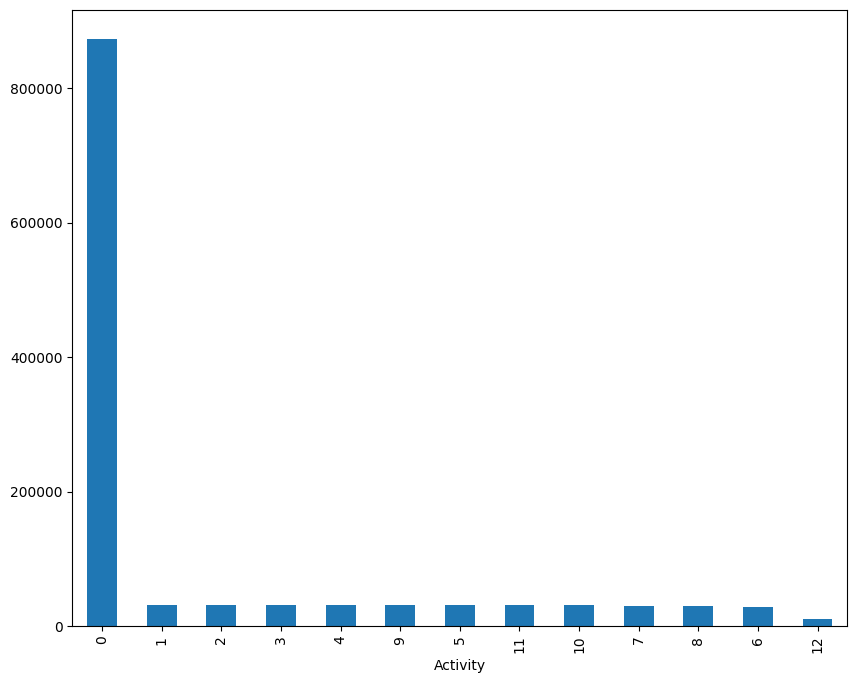

In [11]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [12]:
data_activity_0 =df[df['Activity']==0]
data_activity_else = df[df['Activity'] !=0]

In [13]:
data_activity_0 = data_activity_0.sample(n=40000)
df=pd.concat([data_activity_0, data_activity_else])

<Axes: xlabel='Activity'>

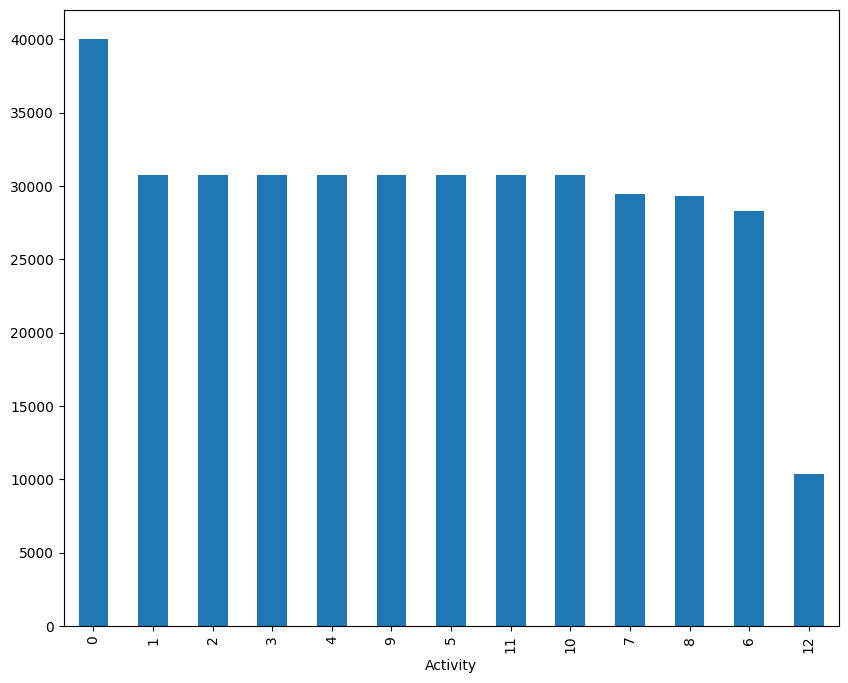

In [14]:
plt.figure(figsize=(10,8))
df['Activity'].value_counts().plot.bar()

In [15]:
len(df)

383195

**Step 3:- EDA**

In [16]:
activity_label={
    0: "None",
    1: "Standing still (1 min)",
    2: "Sitting and relaxing (1 min)",
    3: "Lying down (1 min)",
    4: "Walking (1 min)",
    5: "Climbing stairs (1 min)",
    6: "Waist bends forward (20x)",
    7: "Frontal elevation of arms (20x)",
    8: "Knees bending (crouching) (20x)",
    9: "Cycling (1 min)",
    10: "Jogging (1 min)",
    11: "Running (1 min)",
    12: "Jump front & back (20x)"
}

=============Standing still (1 min) = a=================


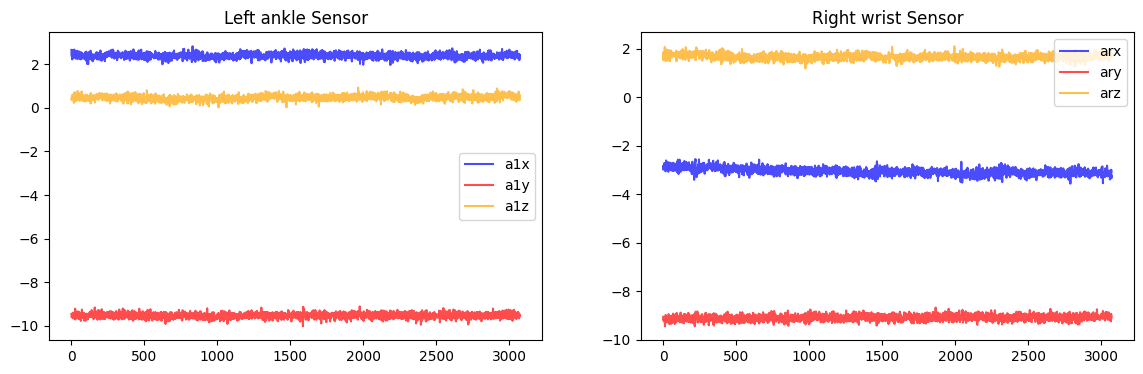

=============Standing still (1 min) = g=================


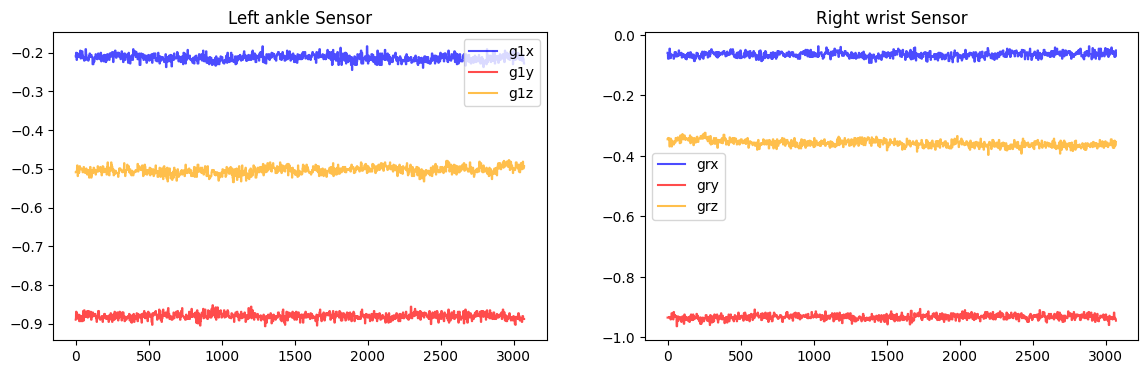

=============Sitting and relaxing (1 min) = a=================


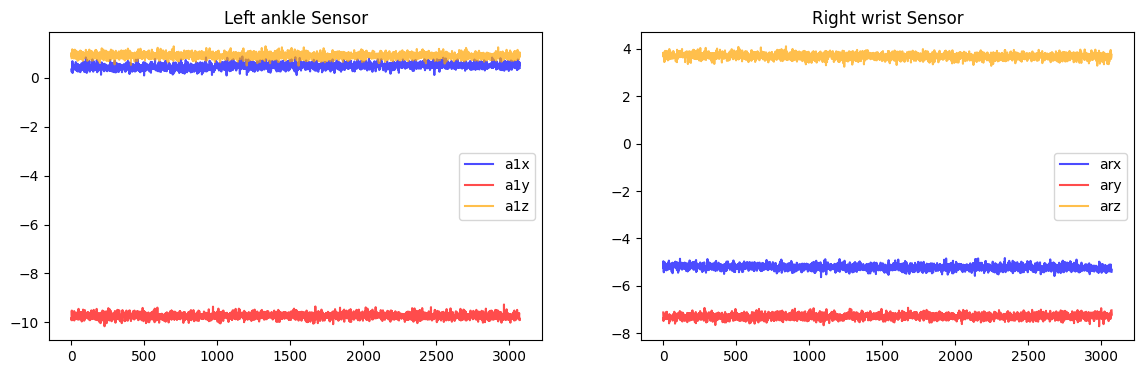

=============Sitting and relaxing (1 min) = g=================


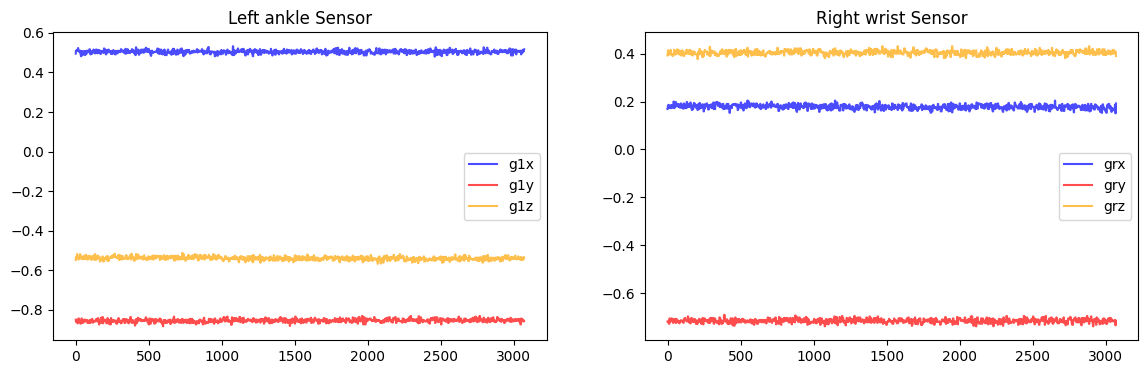

=============Lying down (1 min) = a=================


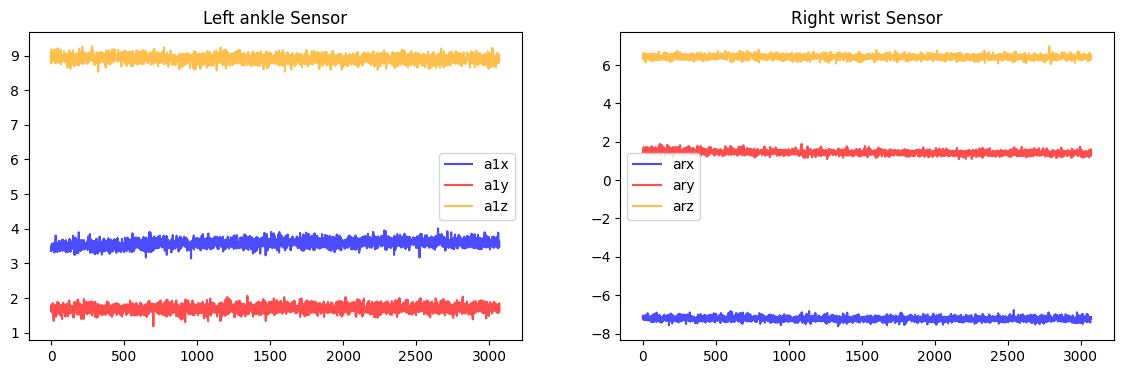

=============Lying down (1 min) = g=================


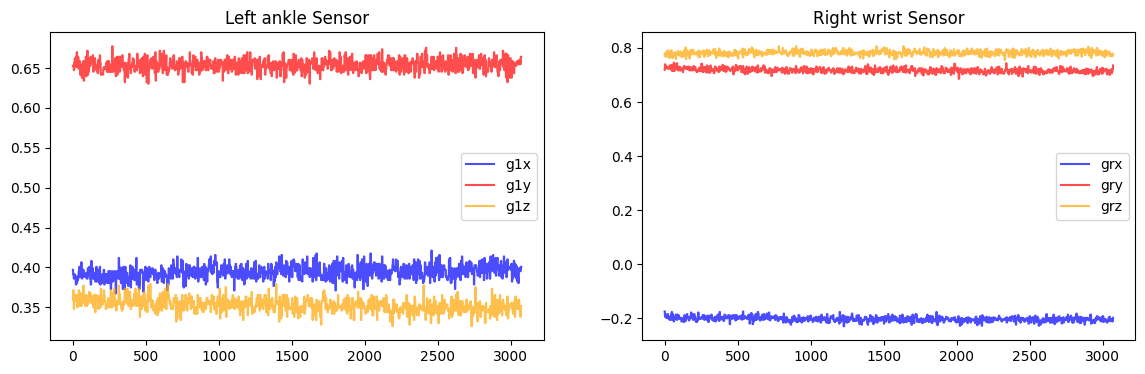

=============Walking (1 min) = a=================


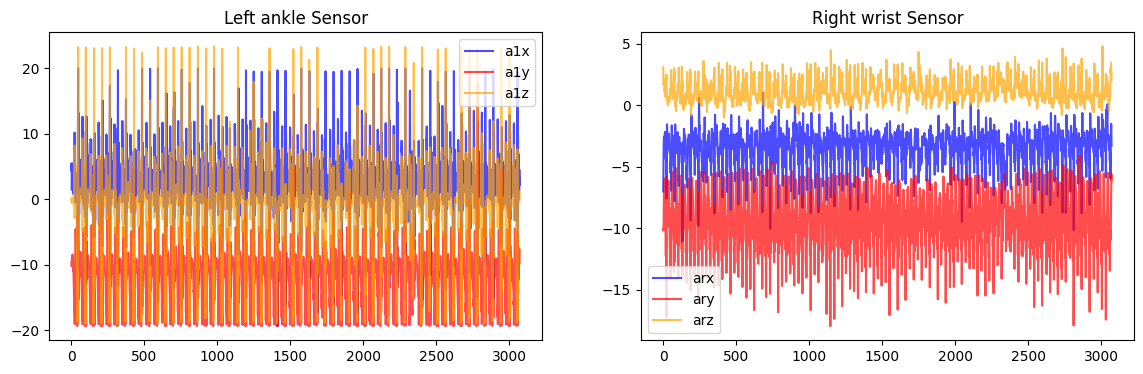

=============Walking (1 min) = g=================


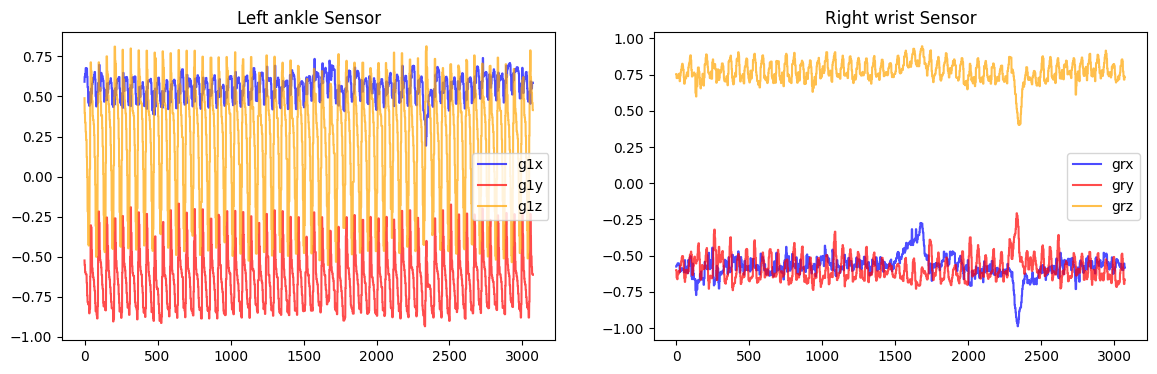

=============Climbing stairs (1 min) = a=================


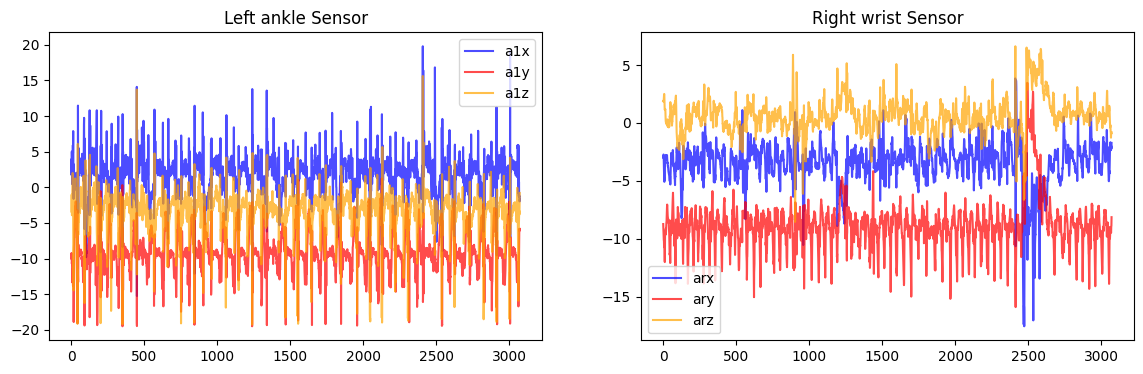

=============Climbing stairs (1 min) = g=================


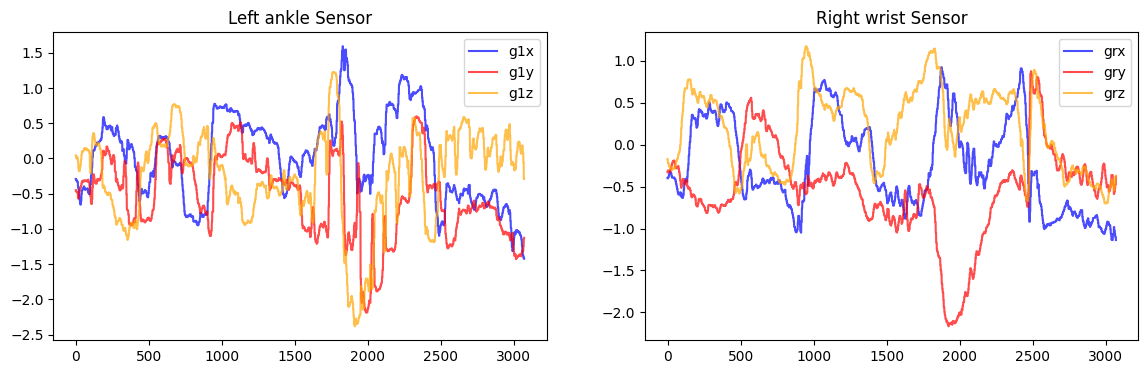

=============Waist bends forward (20x) = a=================


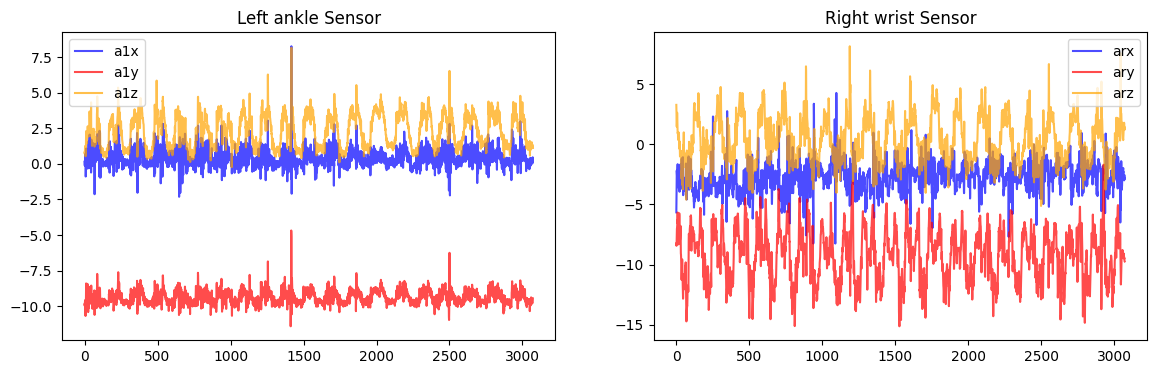

=============Waist bends forward (20x) = g=================


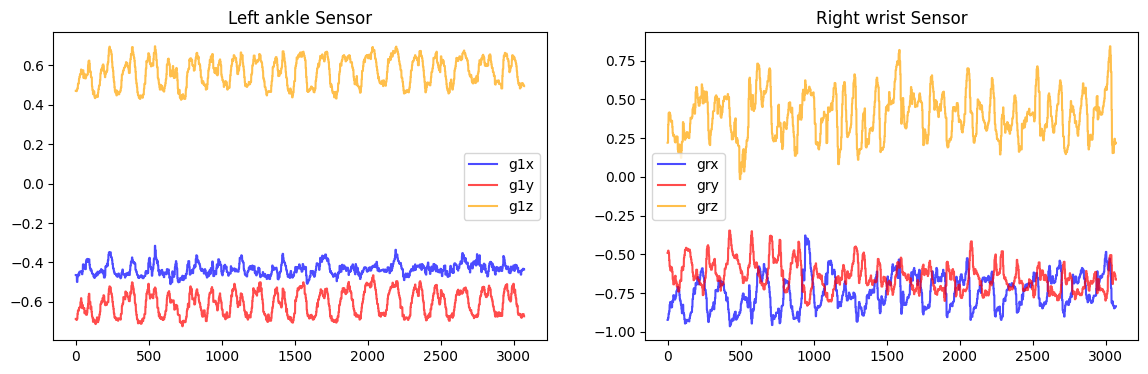

=============Frontal elevation of arms (20x) = a=================


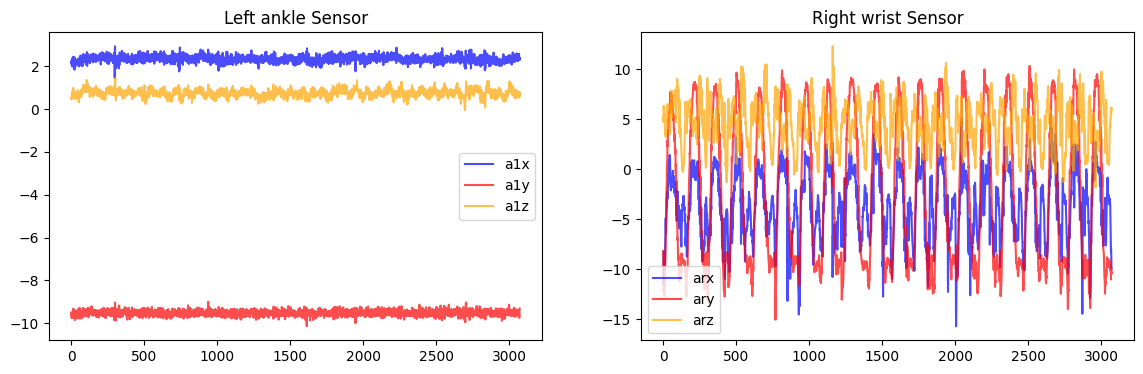

=============Frontal elevation of arms (20x) = g=================


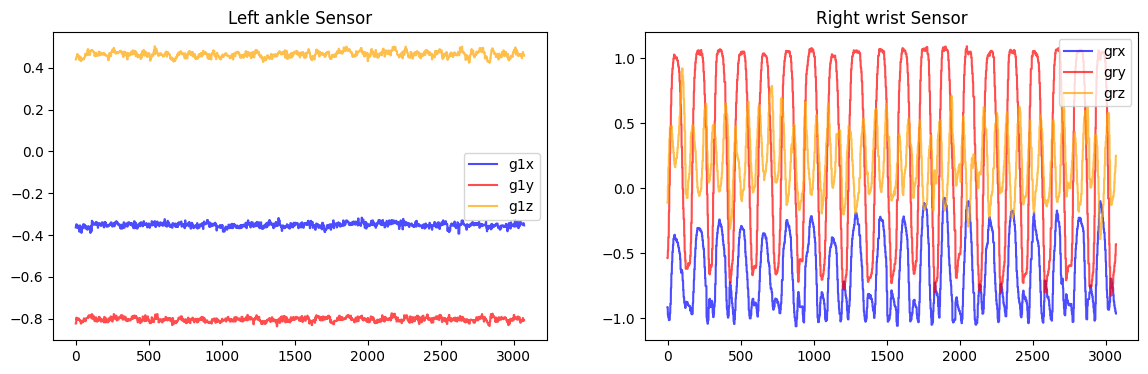

=============Knees bending (crouching) (20x) = a=================


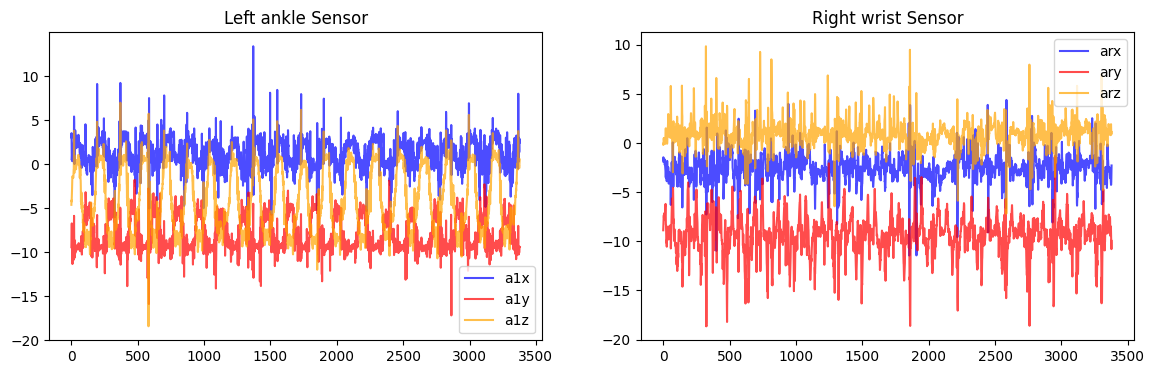

=============Knees bending (crouching) (20x) = g=================


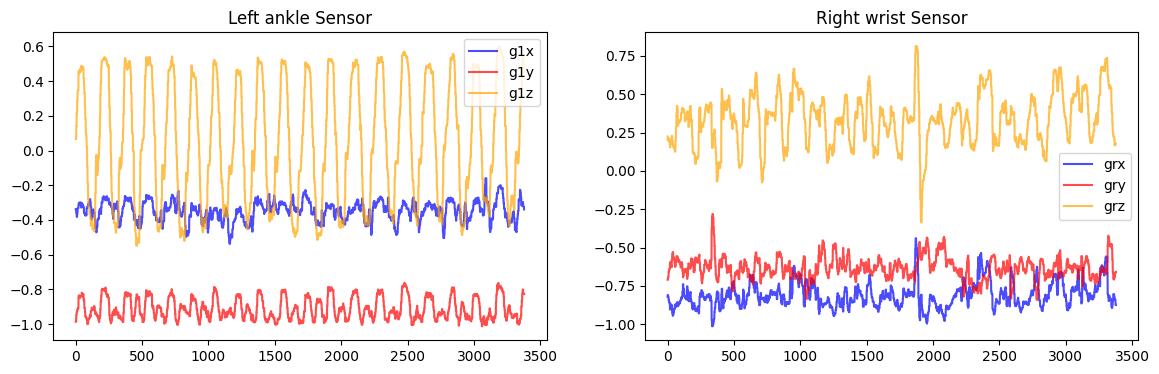

=============Cycling (1 min) = a=================


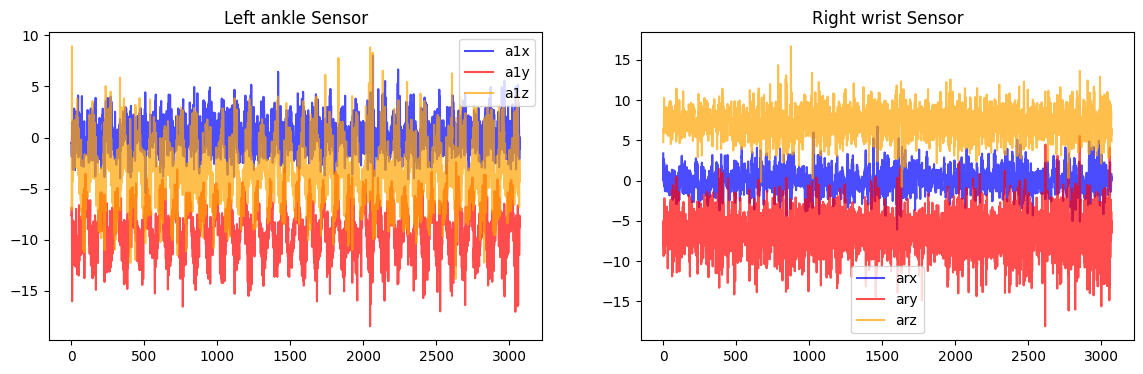

=============Cycling (1 min) = g=================


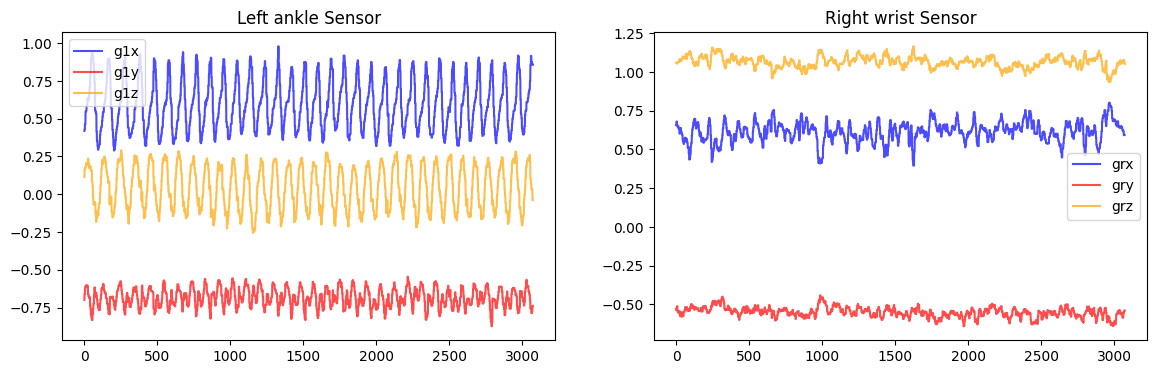

=============Jogging (1 min) = a=================


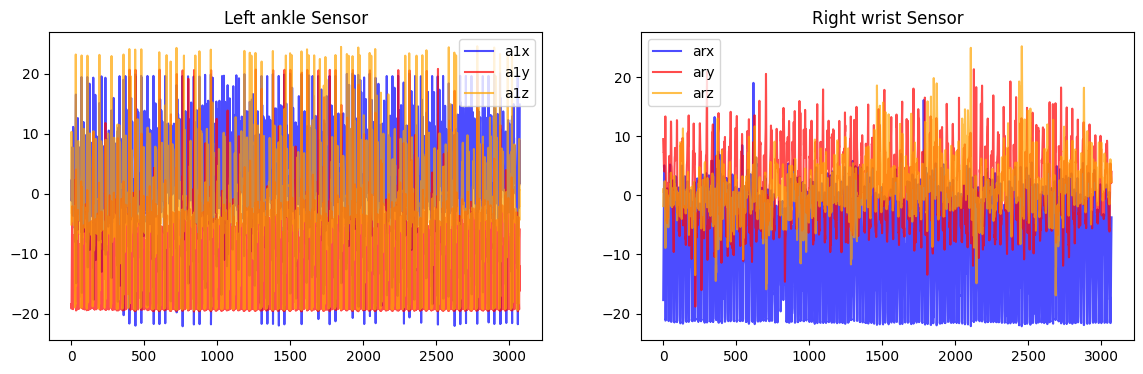

=============Jogging (1 min) = g=================


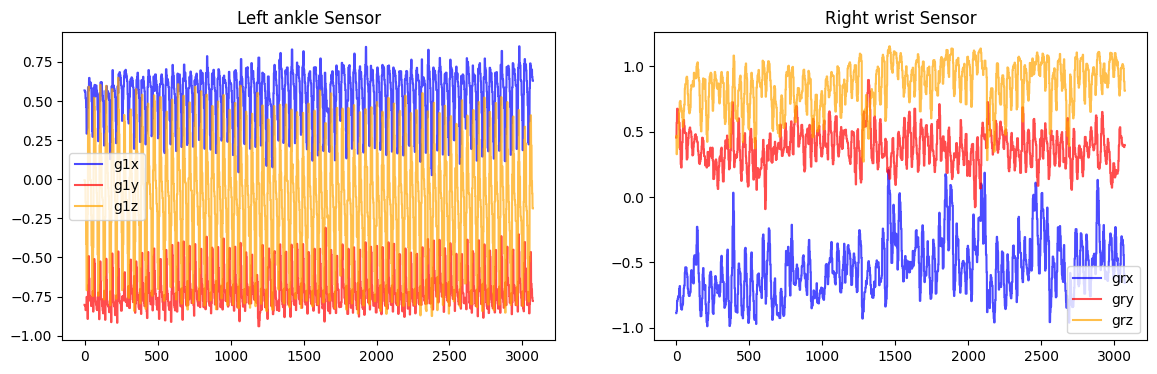

=============Running (1 min) = a=================


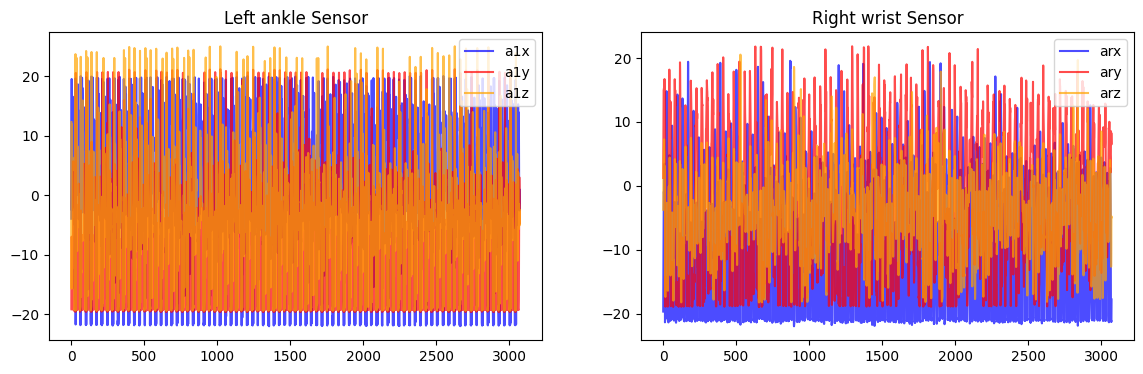

=============Running (1 min) = g=================


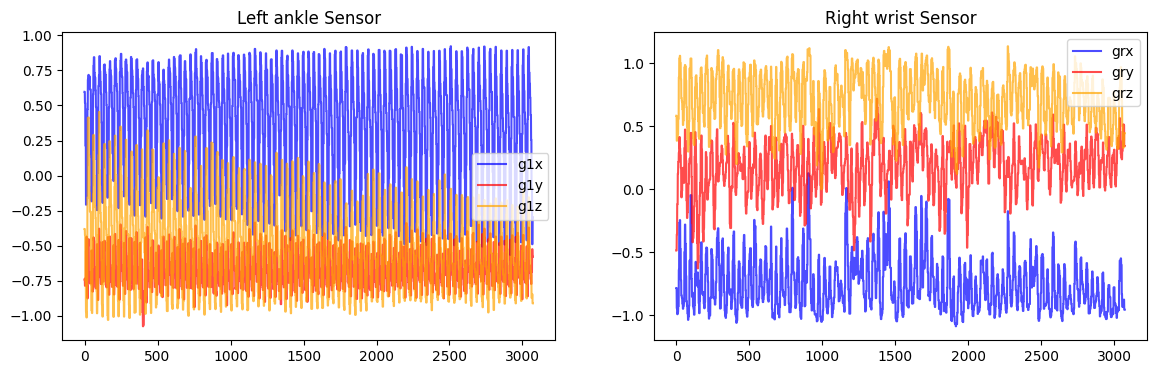

=============Jump front & back (20x) = a=================


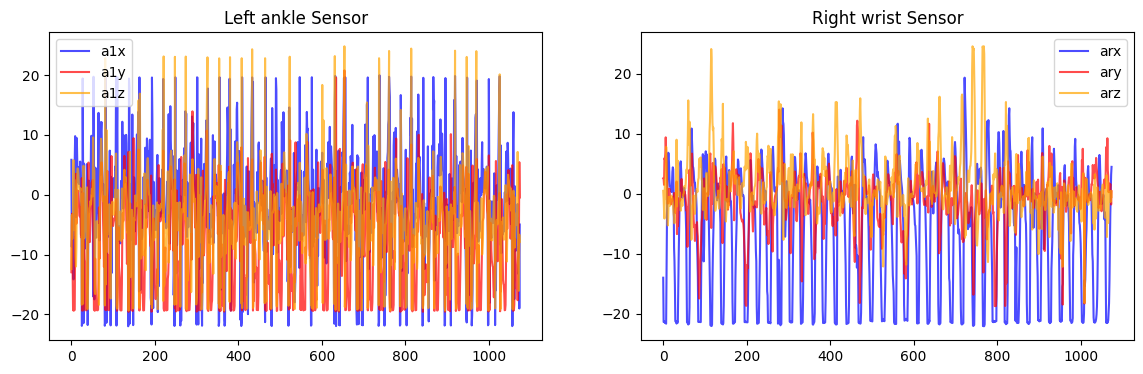

=============Jump front & back (20x) = g=================


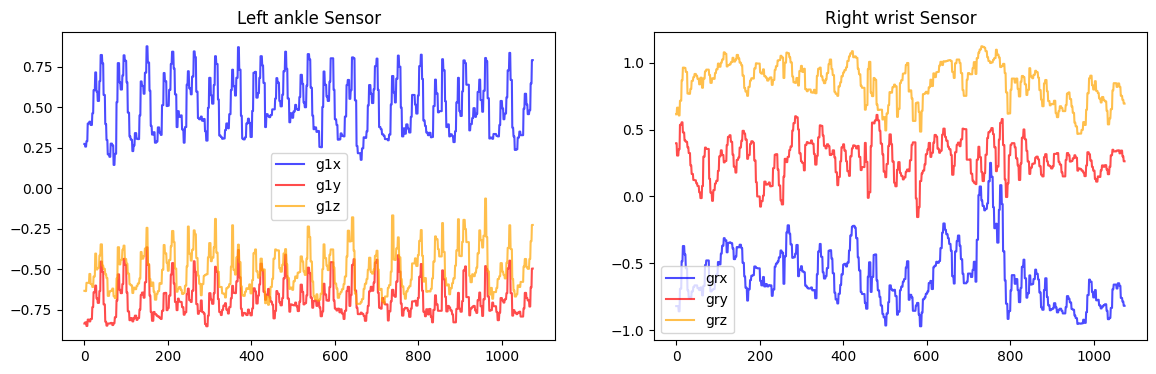

In [17]:
subject1 = df[df['subject'] == 'subject1']
readings = ['a', 'g']

for i in range(1,13):
  for r in readings:
    print(f"============={activity_label[i]} = {r}=================")
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
             color = 'blue', alpha = 0.7, label = r + "1x")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
             color = 'red', alpha = 0.7, label = r + "1y")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
             color = 'orange', alpha = 0.7, label = r + "1z")
    plt.title("Left ankle Sensor")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
             color = 'blue', alpha = 0.7, label = r+ "rx")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
             color = 'red', alpha = 0.7, label = r+ "ry")
    plt.plot(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
             color = 'orange', alpha = 0.7, label = r+ "rz")
    plt.title("Right wrist Sensor")
    plt.legend()
    plt.show()

=============Standing still (1 min) = a=================


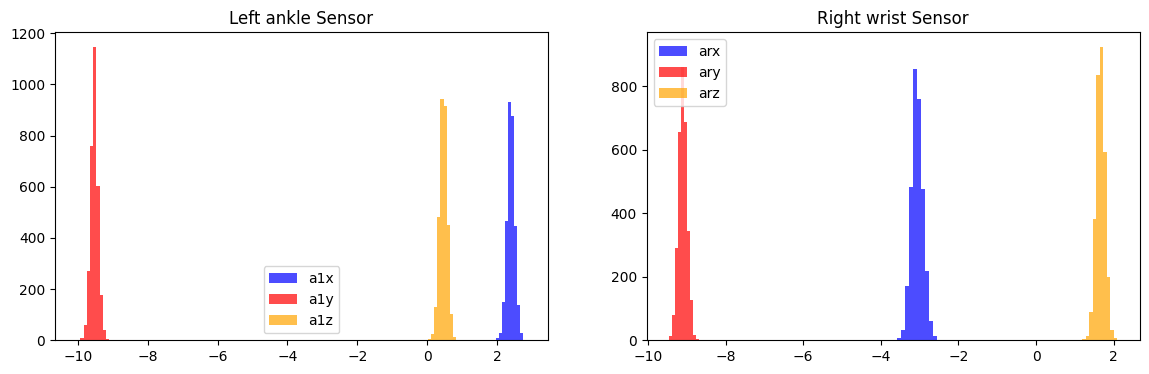

=============Standing still (1 min) = g=================


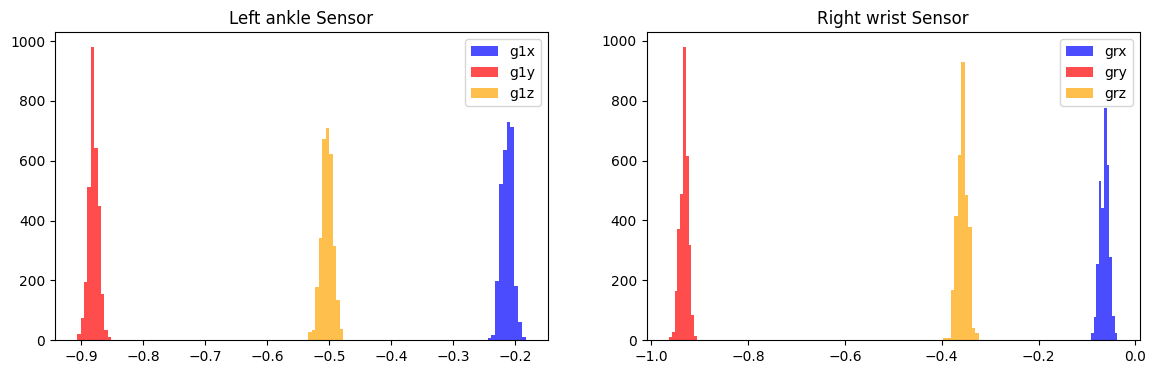

=============Sitting and relaxing (1 min) = a=================


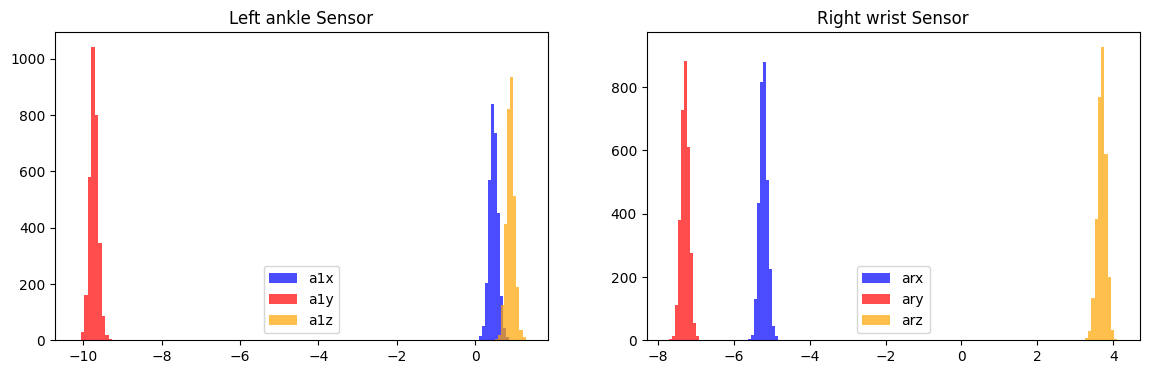

=============Sitting and relaxing (1 min) = g=================


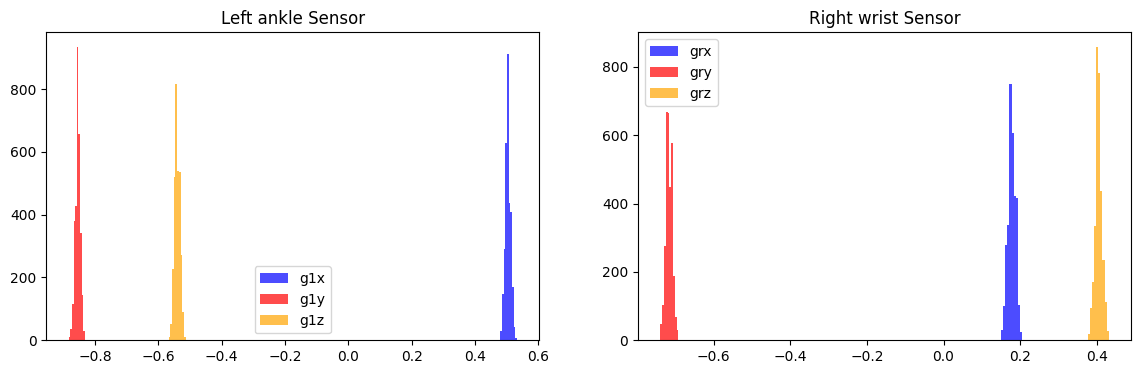

=============Lying down (1 min) = a=================


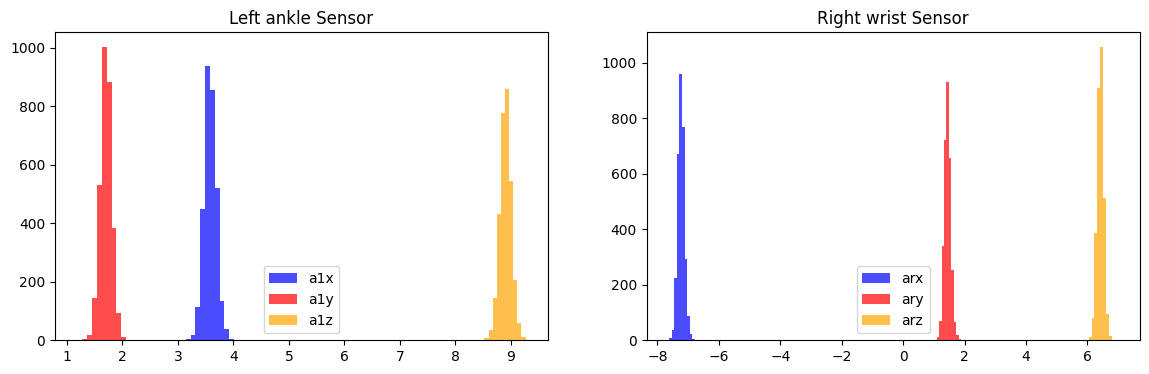

=============Lying down (1 min) = g=================


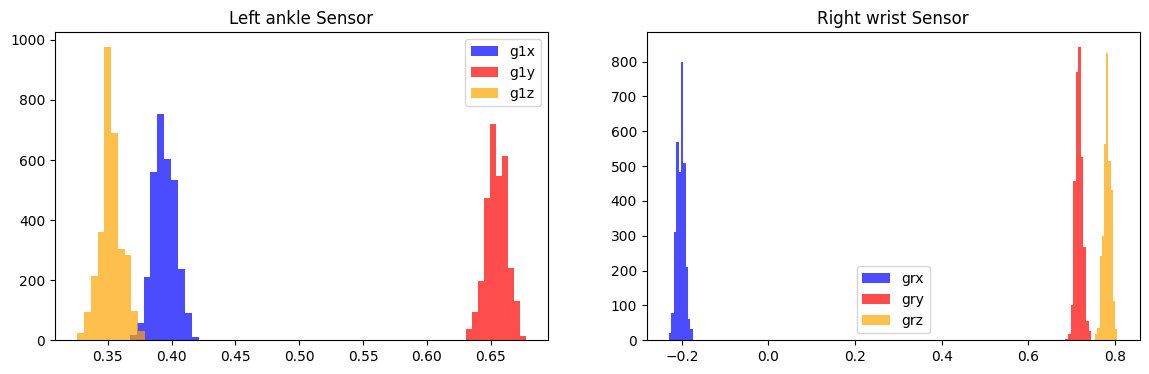

=============Walking (1 min) = a=================


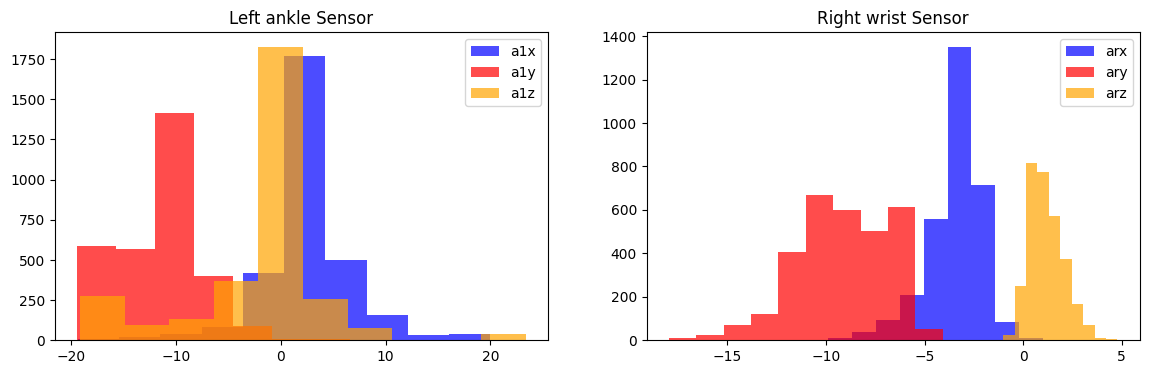

=============Walking (1 min) = g=================


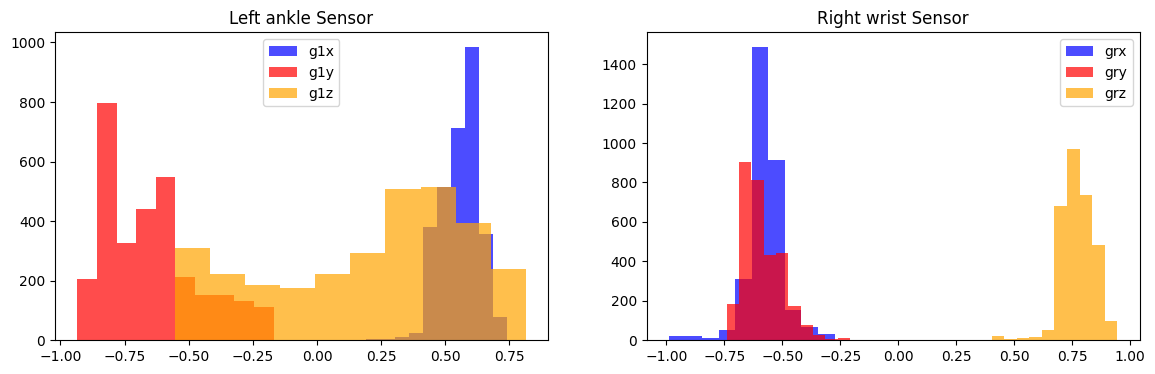

=============Climbing stairs (1 min) = a=================


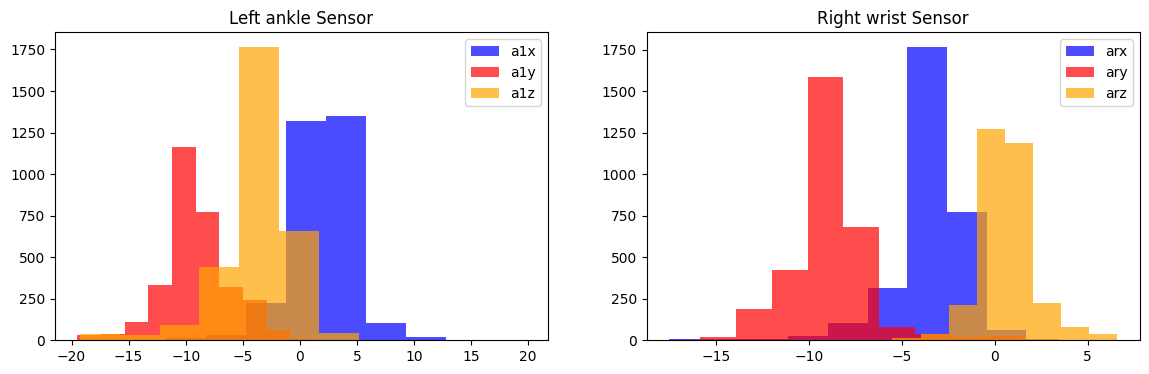

=============Climbing stairs (1 min) = g=================


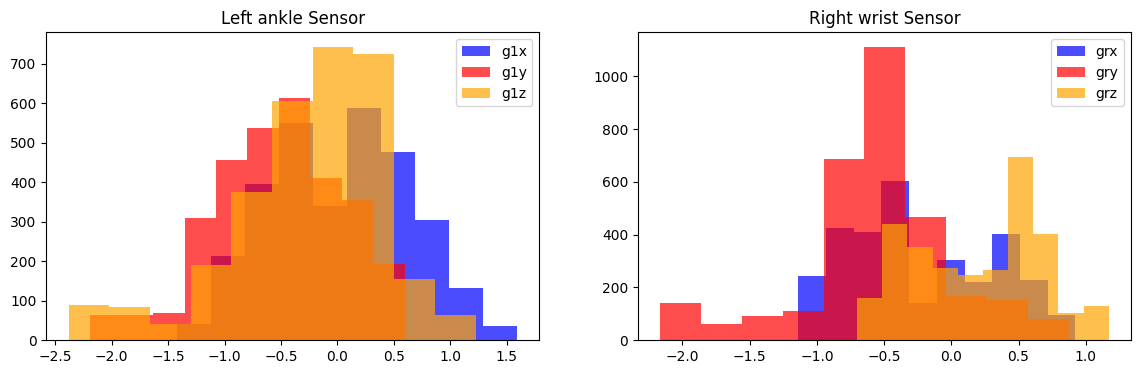

=============Waist bends forward (20x) = a=================


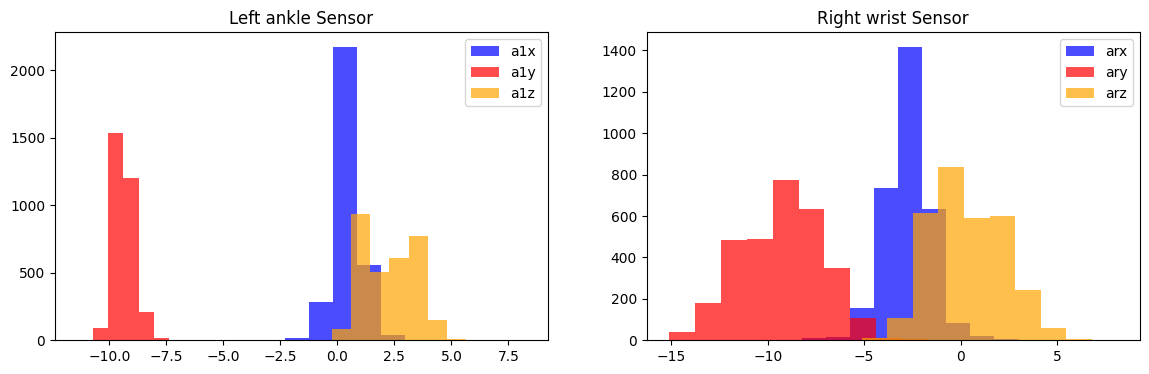

=============Waist bends forward (20x) = g=================


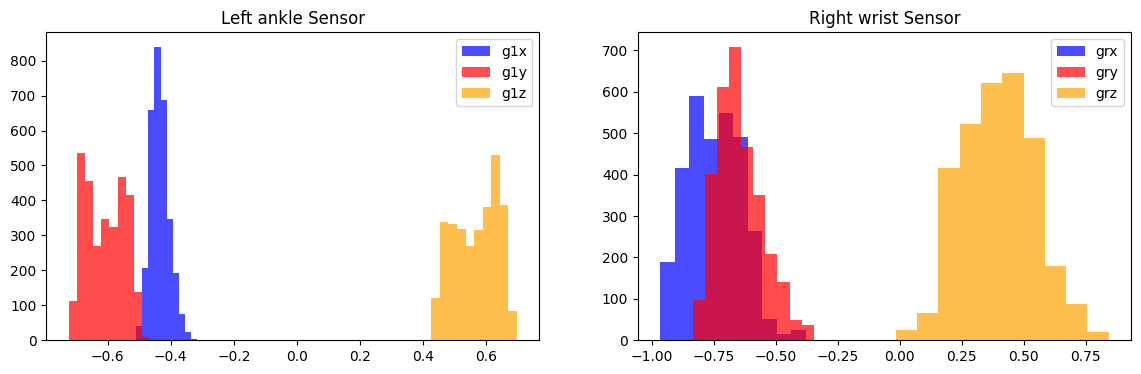

=============Frontal elevation of arms (20x) = a=================


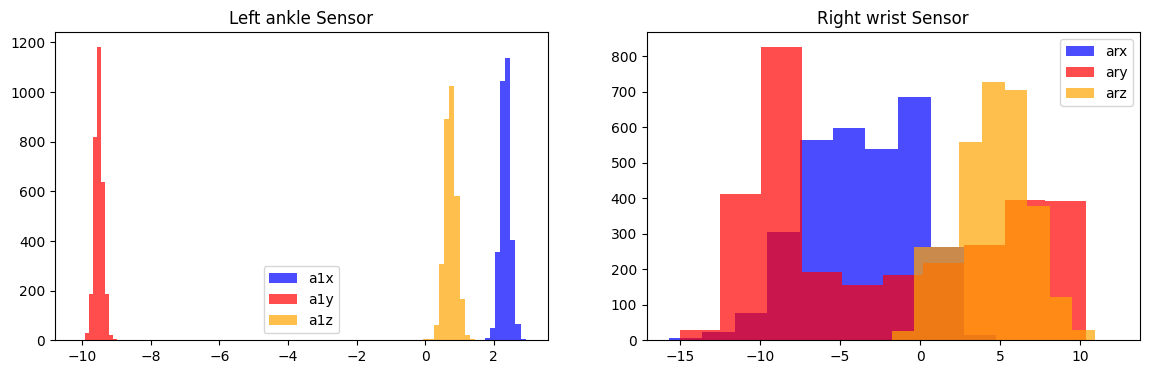

=============Frontal elevation of arms (20x) = g=================


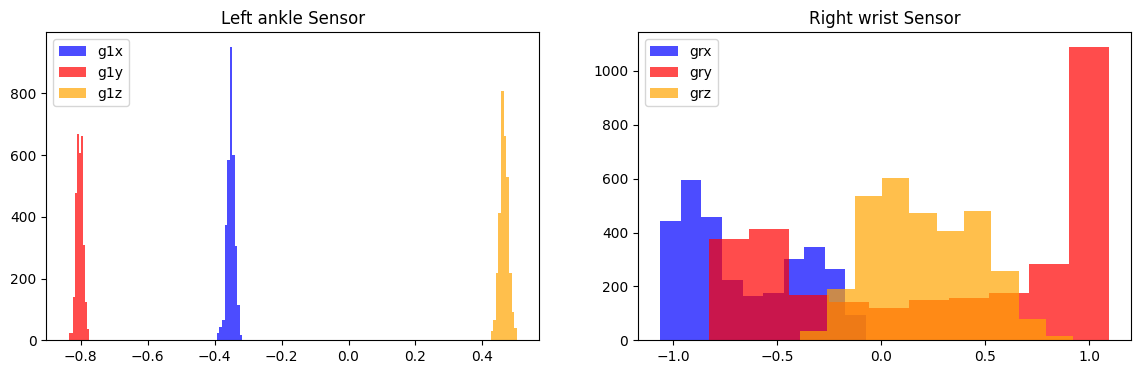

=============Knees bending (crouching) (20x) = a=================


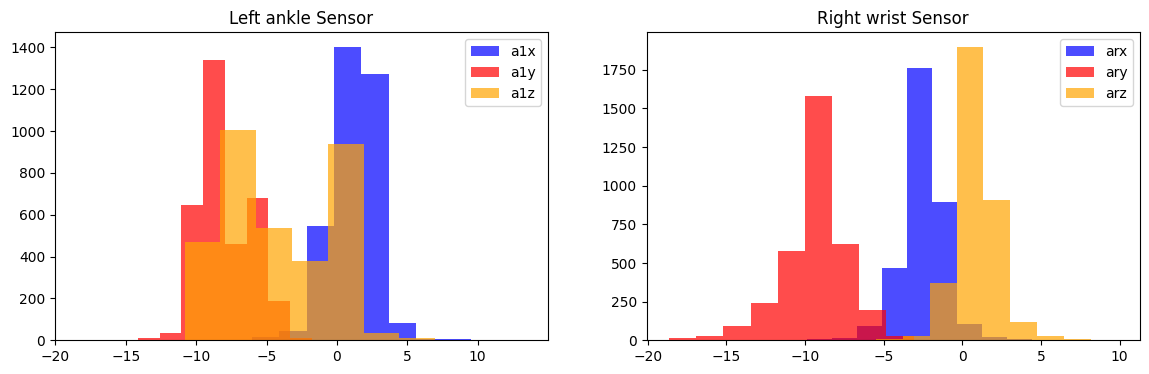

=============Knees bending (crouching) (20x) = g=================


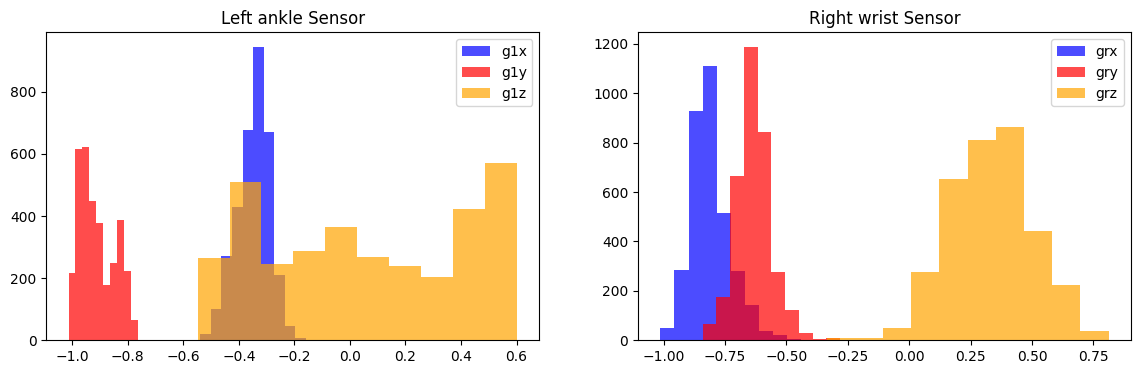

=============Cycling (1 min) = a=================


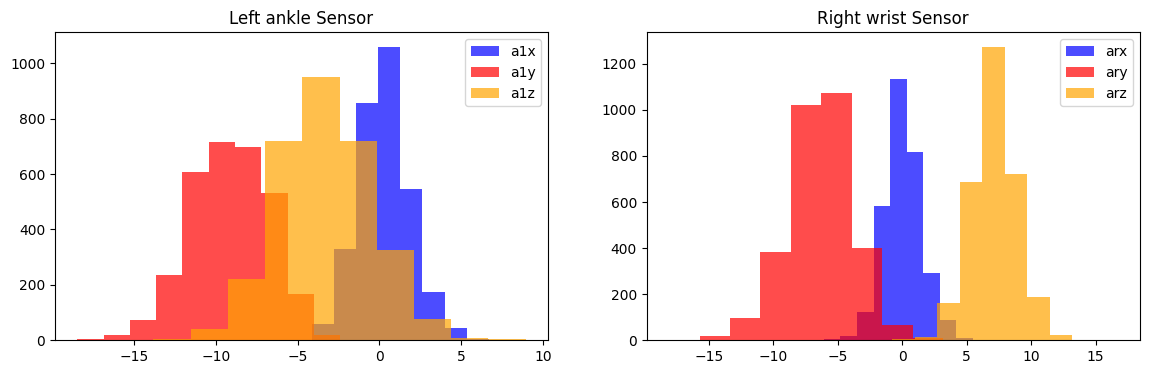

=============Cycling (1 min) = g=================


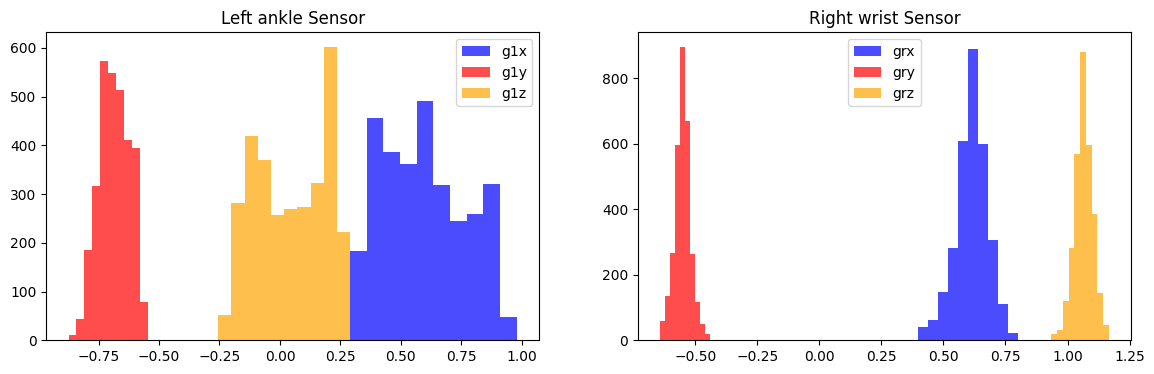

=============Jogging (1 min) = a=================


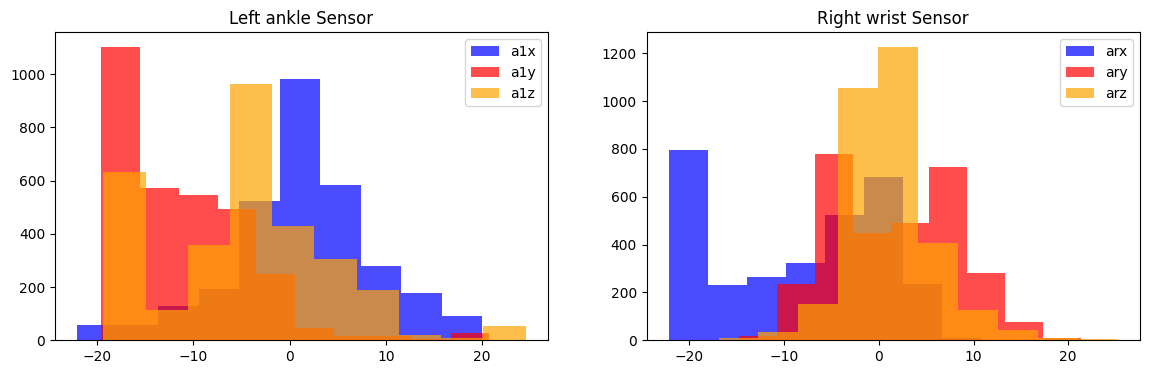

=============Jogging (1 min) = g=================


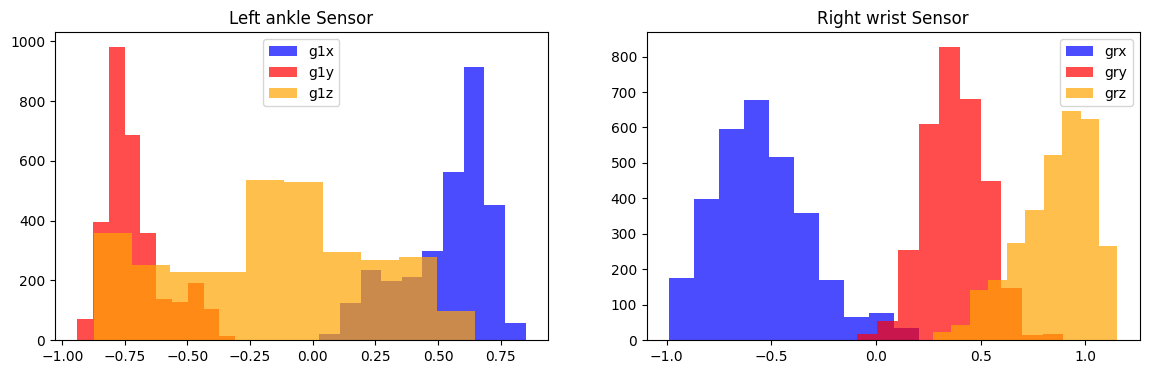

=============Running (1 min) = a=================


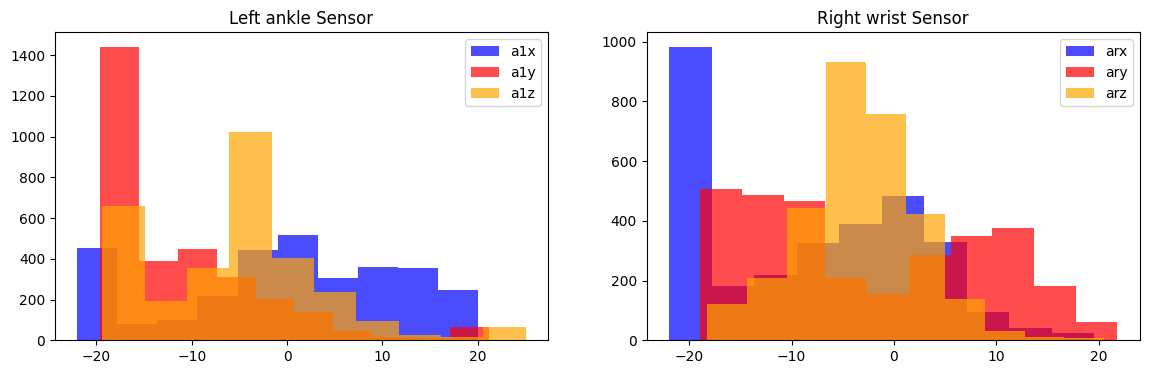

=============Running (1 min) = g=================


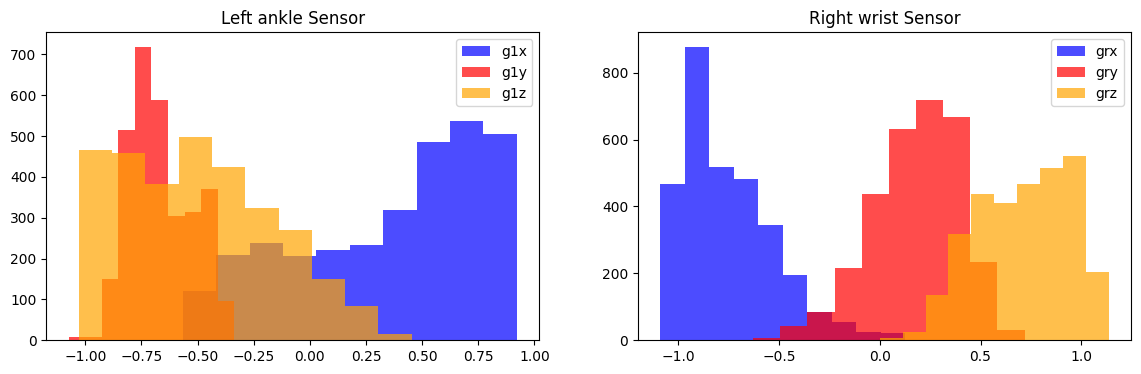

=============Jump front & back (20x) = a=================


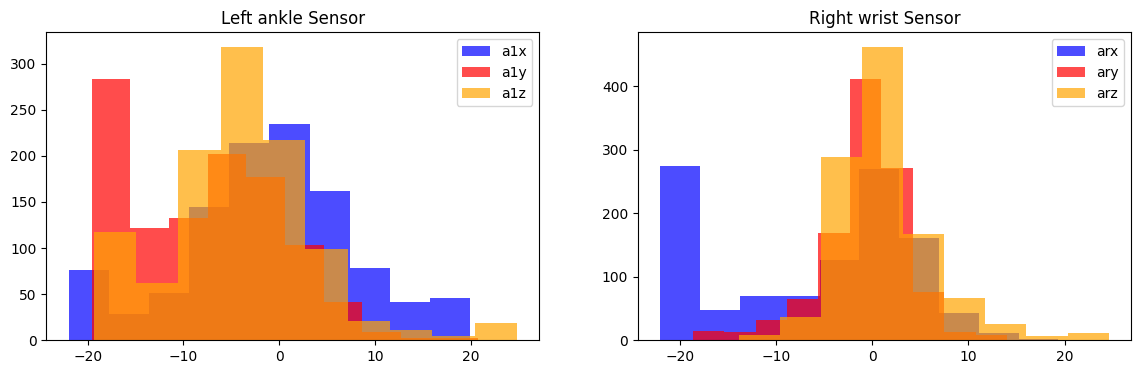

=============Jump front & back (20x) = g=================


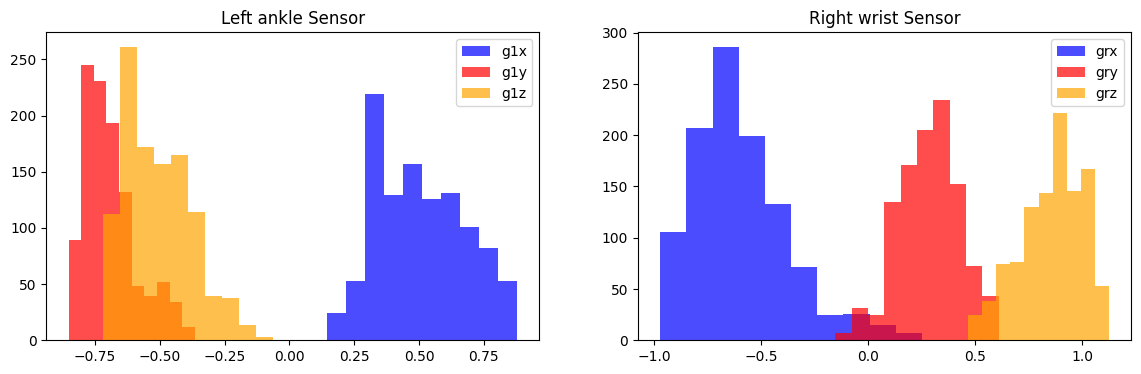

In [18]:
for i in range(1,13):
  for r in readings:
    print(f"============={activity_label[i]} = {r}=================")
    plt.figure(figsize=(14,4))
    plt.subplot(1,2,1)
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lx"],
             color = 'blue', alpha = 0.7, label = r + "1x")
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ly"],
             color = 'red', alpha = 0.7, label = r + "1y")
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "lz"],
             color = 'orange', alpha = 0.7, label = r + "1z")
    plt.title("Left ankle Sensor")
    plt.legend()

    plt.subplot(1,2,2)
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rx"],
             color = 'blue', alpha = 0.7, label = r+ "rx")
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "ry"],
             color = 'red', alpha = 0.7, label = r+ "ry")
    plt.hist(subject1[subject1['Activity'] == i].reset_index(drop=True)[r + "rz"],
             color = 'orange', alpha = 0.7, label = r+ "rz")
    plt.title("Right wrist Sensor")
    plt.legend()
    plt.show()

In [19]:
df['Activity'] = df['Activity'].replace([0,1,2,3,4,5,6,7,8,9,10,11,12],['None',
                                                                      'Standing still (1 min)',
                                                                      'Sitting and relaxing (1 min)',
                                                                      'Lying down (1 min)',
                                                                      'Walking (1 min)',
                                                                      'Climbing stairs (1 min)',
                                                                      'Waist bends forward (1 min)',
                                                                      'Frontal elevation of arms (20x)',
                                                                      'Knees bending (crouching) (20x)',
                                                                      'Cycling (1 min)','Jogging (1 min)',
                                                                      'Running (1 min)','Jump front & back (20x)'])

In [20]:
df["Activity"]

,Activity
198931,None
781598,None
278699,None
1093931,None
821819,None
...,...
1213641,Jump front & back (20x)
1213642,Jump front & back (20x)
1213643,Jump front & back (20x)
1213644,Jump front & back (20x)


In [21]:
df.Activity.value_counts()

,count
Activity,
None,40000
Standing still (1 min),30720
Sitting and relaxing (1 min),30720
Lying down (1 min),30720
Walking (1 min),30720
Cycling (1 min),30720
Climbing stairs (1 min),30720
Running (1 min),30720
Jogging (1 min),30720


<Axes: ylabel='count'>

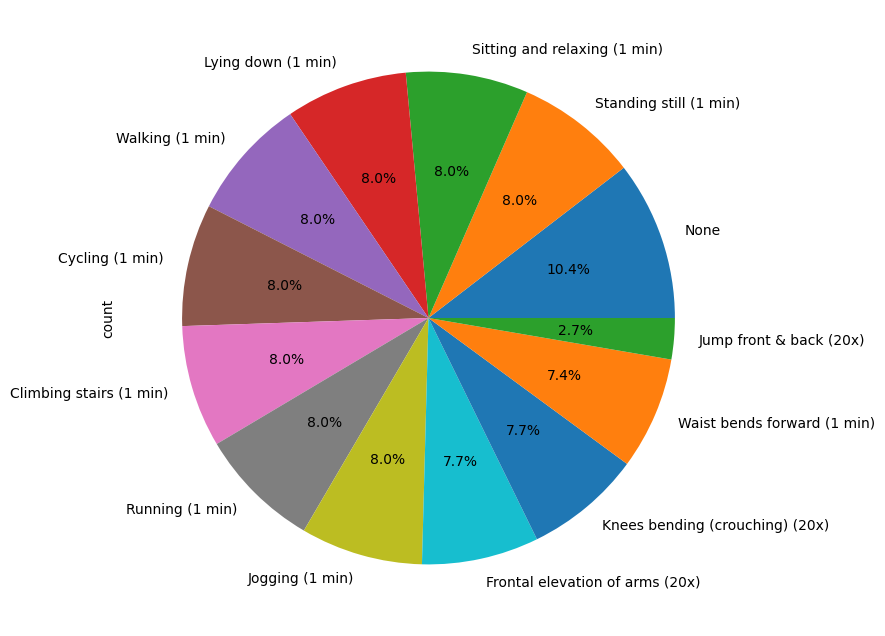

In [22]:
plt.figure(figsize=(12,8))
round(df['Activity'].value_counts()/df.shape[0]*100,2).plot.pie(autopct= '%2.1f%%')

In [23]:
df1 = df.copy()

for feature in df1.columns[:-2]:
  lower_range = np.quantile(df[feature],0.01)
  upper_range = np.quantile(df[feature],0.99)
  print(feature, "range", lower_range, 'to, upper_range')

  df1 = df1.drop(df1[(df1[feature] > upper_range) | (df1[feature] < lower_range)].index, axis=0)
  print('shape', df1.shape)

alx range -11.57706 to, upper_range
shape (375550, 14)
aly range -19.378 to, upper_range
shape (369587, 14)
alz range -18.949 to, upper_range
shape (365771, 14)
glx range -0.75325 to, upper_range
shape (358746, 14)
gly range -1.0694 to, upper_range
shape (352118, 14)
glz range -1.1061 to, upper_range
shape (346441, 14)
arx range -21.487 to, upper_range
shape (341217, 14)
ary range -18.691 to, upper_range
shape (335006, 14)
arz range -10.246 to, upper_range
shape (332341, 14)
grx range -1.0216 to, upper_range
shape (328699, 14)
gry range -1.1437 to, upper_range
shape (323676, 14)
grz range -0.7069 to, upper_range
shape (318958, 14)


In [24]:
df1

,alx,aly,alz,glx,gly,glz,arx,ary,arz,grx,gry,grz,Activity,subject
198931,16.04200,-19.11500,-0.61825,-0.43414,-0.45028,-0.91159,-13.1630,2.064100,0.40529,-0.85098,-0.19302,-0.549570,None,subject2
781598,1.46400,-9.63300,1.05380,0.36735,-0.63227,0.54420,-2.2018,-9.653900,2.61110,-0.27059,-0.62834,0.915950,None,subject7
278699,0.34229,-9.15410,-4.51680,-0.25788,-0.53096,-0.78585,-3.5735,-3.856000,8.40100,-0.44510,-1.07190,0.540950,None,subject2
1093931,2.41630,-5.51990,3.45650,0.49722,-0.66792,-0.55599,-8.4247,-9.128000,-4.80010,-0.48431,-0.60575,0.851290,None,subject9
1204872,-4.83450,-12.25600,-1.82780,-0.32282,-0.92308,-0.38114,-4.1654,-12.330000,-1.04360,-0.32549,-0.98973,-0.344830,None,subject10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213636,-0.19979,-0.93484,2.55540,0.63080,-0.52533,-0.67976,-4.0212,-0.082645,0.73545,-0.45882,-1.00000,0.122840,Jump front & back (20x),subject10
1213637,-0.33315,-1.23710,-2.91940,0.63822,-0.42777,-0.74853,-2.2515,-0.414790,0.52093,-0.41765,-1.03700,0.088362,Jump front & back (20x),subject10
1213640,6.77570,-15.07500,7.39740,0.61967,-0.33771,-0.82711,-2.2797,-2.358900,2.11120,-0.41765,-1.03700,0.088362,Jump front & back (20x),subject10
1213641,-2.48730,-19.23300,3.46140,0.61967,-0.33771,-0.82711,-8.2348,-4.965200,2.48090,-0.43725,-1.01850,0.079741,Jump front & back (20x),subject10


**Step 4:- Data Preprocessing**

In [25]:
le = LabelEncoder()
df['subject'] = le.fit_transform(df['subject'])

In [26]:
df['Activity'] = le.fit_transform(df['Activity'])

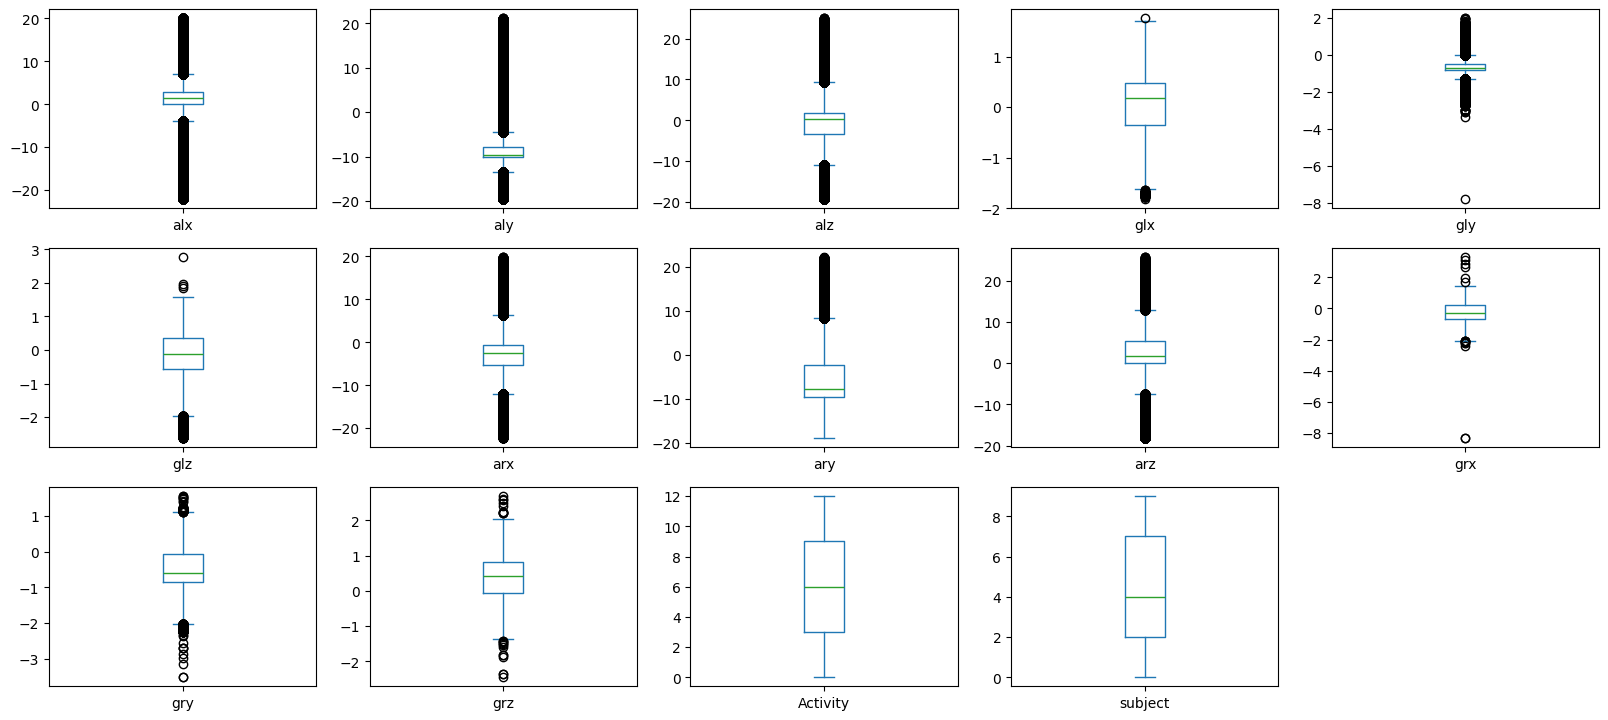

In [27]:
df.plot(kind='box', subplots=True ,  layout = (5,5), figsize=(20,15))
plt.show()

In [28]:
x = df.drop(["Activity", "subject"], axis = 1).values
y= df['Activity'].values

In [29]:
x_train, x_test,y_train, y_test = train_test_split(x, y, test_size=0.25)

In [30]:
ro_scaler = RobustScaler().fit(x_train)
x_train_scaled = ro_scaler.transform(x_train)
x_test_scaled = ro_scaler.transform(x_test)

**Step 5:- Building Model**

In [31]:
def resultSummerizer(y_true, y_pred, cm_en= True):
  cm = confusion_matrix(y_true,y_pred)
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro')
  rec = sensitivity = recall_score(y_true, y_pred, average='macro')
  f1 = f1_score(y_true, y_pred, average='macro')

  if cm_en:
    plt.figure(figsize=(15,15))

    sns.heatmap(cm, annot= True, cmap = "Blues", xticklabels=activity_label.values(),
              yticklabels=activity_label.values())
    plt.title('Confusion Matrix')
    plt.show()

  #print(classification_report(y_true, y_pred))
  print(f'Accuracy Score: '+'{:.4%}'.format(acc))
  print(f'Precision Score: '+'{:.4%}'.format(prec))
  print(f'Recall Score: '+'{:.4%}'.format(rec))
  print(f'F1 Score: '+'{:.4%}'.format(f1))


***1. LogisticRegression()***

In [32]:
lr = LogisticRegression()
lr.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [33]:
lr.score(x_train, y_train)

0.5422483263510974

In [34]:
lr.score(x_test, y_test)

0.5459347174813933

In [35]:
lr2 = LogisticRegression()
lr2.fit(x_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [36]:
lr2.score(x_train_scaled, y_train)

0.5512498434216203

In [37]:
lr2.score(x_test_scaled, y_test)

0.5544629902191046

In [38]:
y_pred_lr = lr.predict(x_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


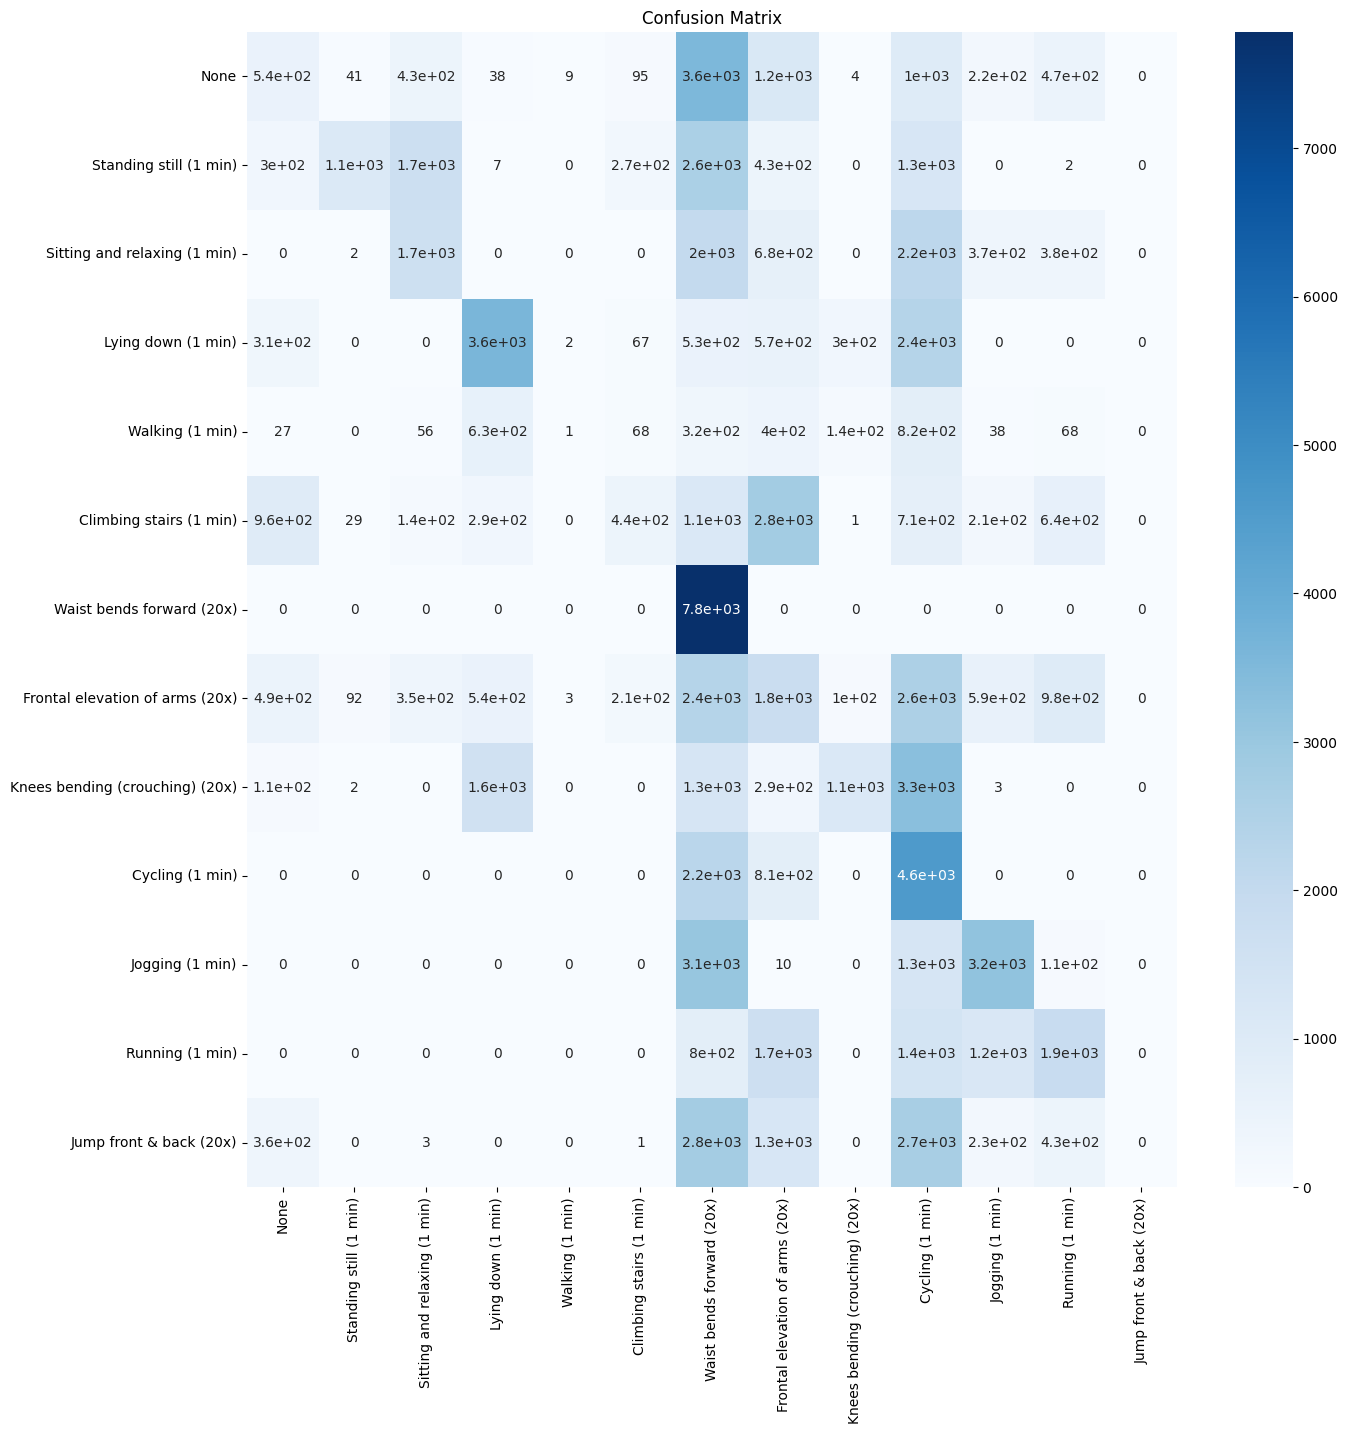

Accuracy Score: 28.8959%
Precision Score: 35.3098%
Recall Score: 27.5100%
F1 Score: 23.9496%


In [39]:
resultSummerizer(y_test, y_pred_lr)

***2. KNN***

In [40]:
knn1 = KNeighborsClassifier(n_neighbors=5)
knn1.fit(x_train, y_train)

KNeighborsClassifier()

In [41]:
y_pred_knn = knn1.predict(x_test)

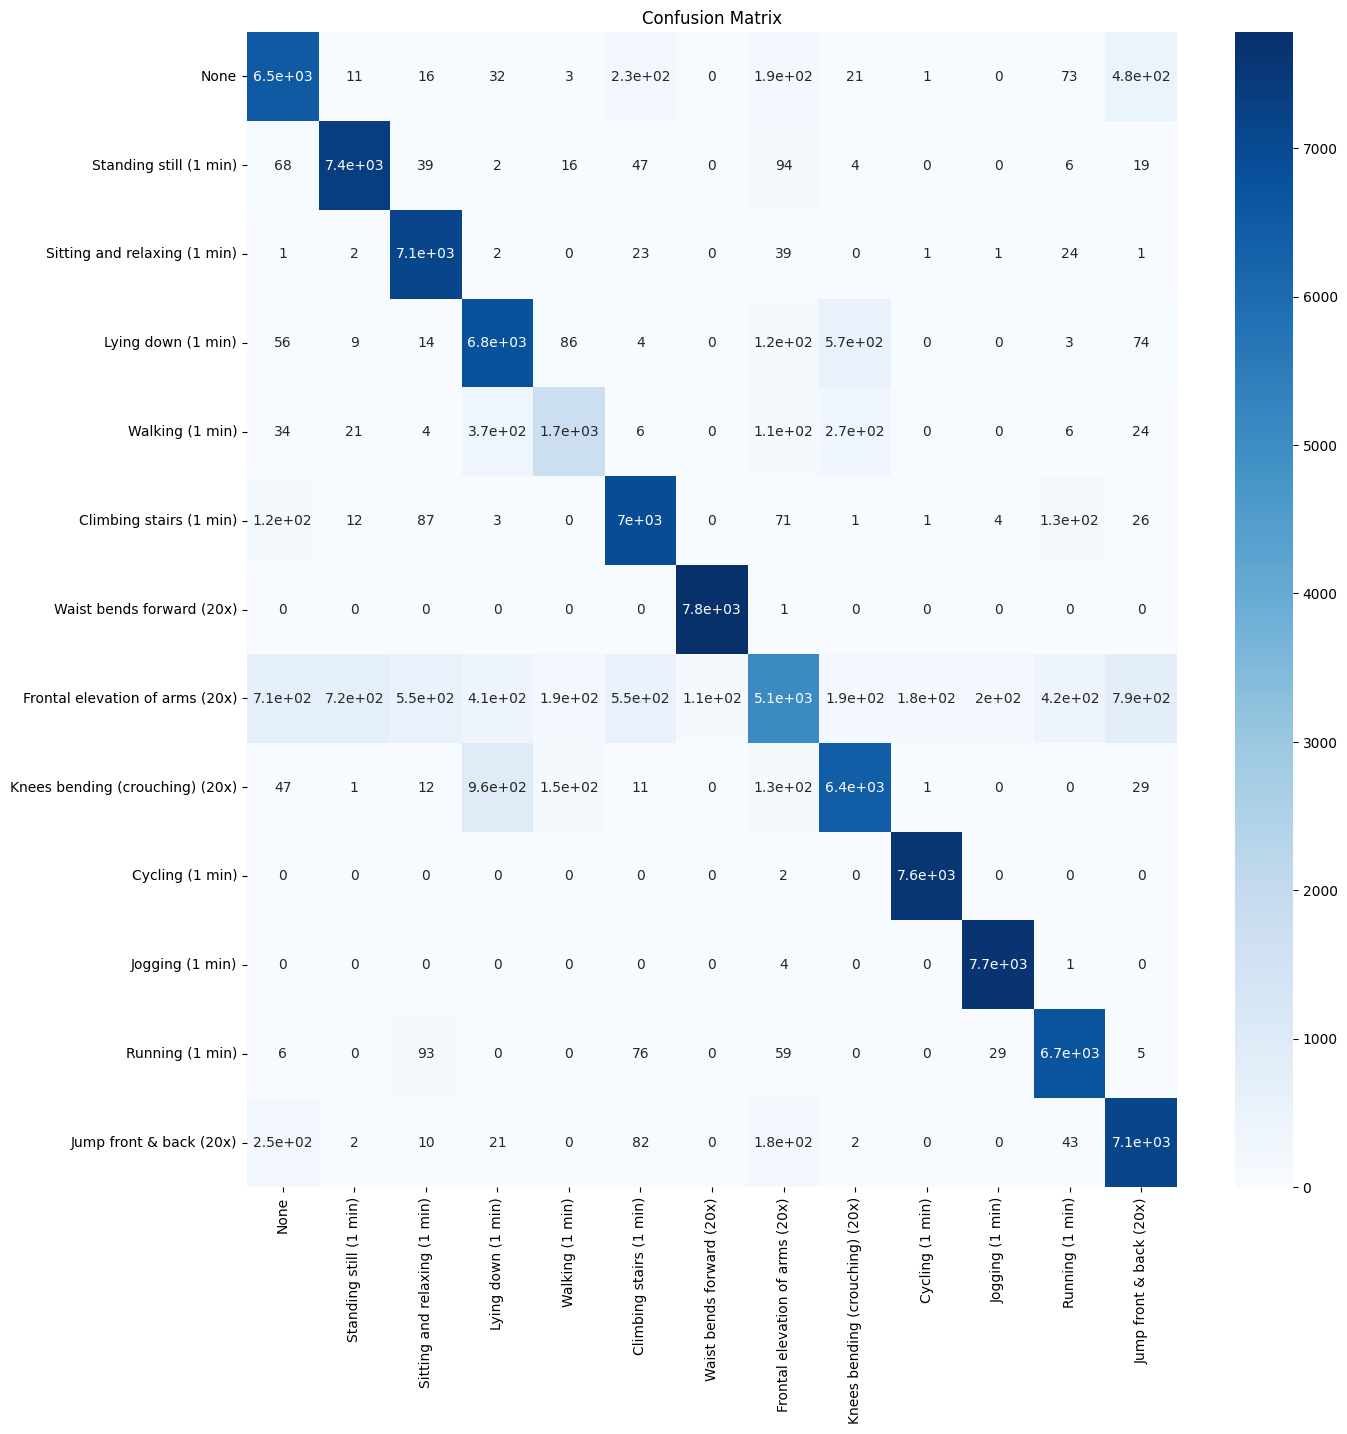

Accuracy Score: 88.5865%
Precision Score: 88.0818%
Recall Score: 88.5202%
F1 Score: 87.8604%


In [42]:
resultSummerizer(y_test, y_pred_knn)

In [43]:
knn2 = KNeighborsClassifier(n_neighbors=5)
knn2.fit(x_train_scaled, y_train)
y_pred_knn2 = knn2.predict(x_test_scaled)

In [44]:
resultSummerizer(y_test, y_pred_knn2, cm_en=False)

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%


In [45]:
for n in range(1,11):
  knn = KNeighborsClassifier(n_neighbors=n)
  knn.fit(x_train_scaled, y_train)
  y_pred = knn.predict(x_test_scaled)
  print("\n============No of Neighbors: {n}=================\n")
  resultSummerizer(y_test, y_pred_knn2, cm_en=False)


============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%

============No of Neighbors: {n}=================

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 S

In [47]:
dt = DecisionTreeClassifier(max_depth=14)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
resultSummerizer(y_test, y_pred_knn2, cm_en=False)

Accuracy Score: 93.7254%
Precision Score: 93.6046%
Recall Score: 93.5844%
F1 Score: 93.2244%
